
# Integración geométrica de una partícula cargada en un campo eléctrico dependiente del tiempo
## Extensión Hamiltoniana · Splitting · Integrador de Strang

Este cuaderno estudia numéricamente la dinámica de una partícula cargada en $\mathbb{R}^2$
bajo la acción de un campo eléctrico homogéneo dependiente del tiempo, usando:

1. **Extensión Hamiltoniana** para convertir un sistema no autónomo en uno autónomo symplectico.
2. **Splitting del Hamiltoniano extendido** en partes con flujo integrable.
3. **Integrador symplectico de Strang** (composición simétrica).
4. **Comparación con RK4**, análisis de energía, orden y volumen de fase.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from numpy.linalg import norm, det

plt.style.use("seaborn-v0_8")



## 1. Modelo físico y Hamiltoniano no autónomo

Consideramos una partícula de masa $m$ y carga $e$ moviéndose en $\mathbb{R}^2$ con posición
$q \in \mathbb{R}^2$ y momento $p \in \mathbb{R}^2$. El campo eléctrico es homogéneo en el espacio
y depende del tiempo $t$, denotado por $E(t) \in \mathbb{R}^2$.

El Hamiltoniano no autónomo es
$$
H(q,p,t) = \frac{\|p\|^2}{2m} - e\, q\cdot E(t).
$$

Las ecuaciones de Hamilton son
$$
\dot q = \frac{p}{m}, \qquad
\dot p = e\,E(t), \qquad
\dot t = 1.
$$


In [2]:
# Parámetros físicos
m = 1.0
e = 1.0

def make_field(omega=0.5):
    """Devuelve E(t), E_dot(t) para una frecuencia dada omega."""
    def E(t):
        return np.array([np.sin(omega*t), np.cos(omega*t)])
    def E_dot(t):
        return np.array([omega*np.cos(omega*t), -omega*np.sin(omega*t)])
    return E, E_dot

# Campo eléctrico base
omega_base = 0.5
E_func, E_dot_func = make_field(omega_base)

def H_physical(q, p, t):
    """Hamiltoniano físico H(q,p,t) = |p|^2/(2m) - e q·E(t)."""
    return 0.5 * np.dot(p, p) / m - e * np.dot(q, E_func(t))



## 2. Extensión Hamiltoniana y splitting

Introducimos una variable $E$ conjugada a $t$ y definimos el Hamiltoniano extendido
$$
\widehat H(q,p,t,E) = H(q,p,t) + E
= \frac{\|p\|^2}{2m} - e\, q\cdot E(t) + E,
$$
que es autónomo. Usamos la forma symplectica extendida
$$
\Omega = dq \wedge dp + dE \wedge dt
$$
(en notación compacta).

Para aplicar un integrador symplectico por splitting, escribimos
$$
\widehat H = A + B,
$$
con
$$
A(q,p,t,E) = \frac{\|p\|^2}{2m} + \frac12 E, \qquad
B(q,p,t,E) = -e\, q\cdot E(t) + \frac12 E.
$$

Cada parte genera un flujo (casi) integrable explícitamente.


In [3]:
def strang_step(q, p, t, Eext, dt, E_func, E_dot_func):
    """Un paso del integrador de Strang en el espacio extendido (q,p,t,Eext)."""
    # Flujo de A durante dt/2:
    q = q + 0.5 * dt * (p / m)
    t = t + 0.5 * dt * 0.5  # dt/2 * (dt/dtau = 1/2)

    # Flujo de B durante dt (punto medio en t para orden 2)
    t_mid = t + 0.5 * dt * 0.5
    p = p + dt * e * E_func(t_mid)
    Eext = Eext + dt * e * np.dot(q, E_dot_func(t_mid))
    t = t + dt * 0.5

    # Flujo de A durante dt/2 otra vez
    q = q + 0.5 * dt * (p / m)
    t = t + 0.5 * dt * 0.5

    return q, p, t, Eext


In [4]:
def rk4_step(q, p, t, dt, E_func):
    """Un paso de método de Runge–Kutta 4 clásico en (q,p)."""
    def f_q(p): return p/m
    def f_p(t): return e * E_func(t)

    k1q = f_q(p)
    k1p = f_p(t)

    k2q = f_q(p + 0.5*dt*k1p)
    k2p = f_p(t + 0.5*dt)

    k3q = f_q(p + 0.5*dt*k2p)
    k3p = f_p(t + 0.5*dt)

    k4q = f_q(p + dt*k3p)
    k4p = f_p(t + dt)

    q_new = q + dt*(k1q + 2*k2q + 2*k3q + k4q)/6
    p_new = p + dt*(k1p + 2*k2p + 2*k3p + k4p)/6

    return q_new, p_new, t + dt


In [5]:
def simulate_strang(q0, p0, t0, E0, dt, steps, E_func, E_dot_func):
    q, p, t, Eext = q0.copy(), p0.copy(), t0, E0
    traj, mom, times, Hs, Hexts = [], [], [], [], []
    for _ in range(steps):
        traj.append(q.copy())
        mom.append(p.copy())
        times.append(t)
        H = H_physical(q, p, t)
        Hs.append(H)
        Hexts.append(H + Eext)
        q, p, t, Eext = strang_step(q, p, t, Eext, dt, E_func, E_dot_func)
    return (np.array(traj), np.array(mom),
            np.array(times), np.array(Hs), np.array(Hexts))

def simulate_rk4(q0, p0, t0, dt, steps, E_func):
    q, p, t = q0.copy(), p0.copy(), t0
    traj, mom, times, Hs = [], [], [], []
    for _ in range(steps):
        traj.append(q.copy())
        mom.append(p.copy())
        times.append(t)
        Hs.append(H_physical(q, p, t))
        q, p, t = rk4_step(q, p, t, dt, E_func)
    return np.array(traj), np.array(mom), np.array(times), np.array(Hs)



## 3. Backward error analysis (BEA) — interpretación geométrica

El backward error analysis para integradores symplecticos dice, de manera informal, que
el método numérico no sigue exactamente el flujo del Hamiltoniano original $\widehat H$,
sino el de un **Hamiltoniano modificado** cercano:
$$
\widehat H_{\text{mod}}
= \widehat H + \Delta t^2 H_2 + \Delta t^4 H_4 + \cdots.
$$

Consecuencias:

1. La energía extendida $H(q,p,t) + E$ se conserva casi exactamente (oscila pero sin deriva secular).
2. El método preserva estructuras geométricas globales: volumen de fase, invariantes aproximados, etc.
3. Al proyectar de $(q,p,t,E)$ a $(q,p,t)$, las trayectorias numéricas reproducen fenómenos cualitativos
   del sistema no autónomo original de forma robusta a largo plazo.

En las secciones siguientes verificamos numéricamente estos hechos.


In [6]:
# Parámetros de integración
dt = 0.01
steps = 4000

# Condiciones iniciales
q0 = np.array([0.0, 0.0])
p0 = np.array([1.0, 0.0])
t0 = 0.0
E0 = 0.0

# Simulación con Strang (symplectico extendido)
traj_s, mom_s, times_s, H_s, Hext_s = simulate_strang(
    q0, p0, t0, E0, dt, steps, E_func, E_dot_func
)

# Simulación con RK4 (no symplectico)
traj_r, mom_r, times_r, H_r = simulate_rk4(
    q0, p0, t0, dt, steps, E_func
)



## 4. Resultados numéricos: Strang vs RK4

### 4.1 Trayectorias en el plano de configuración


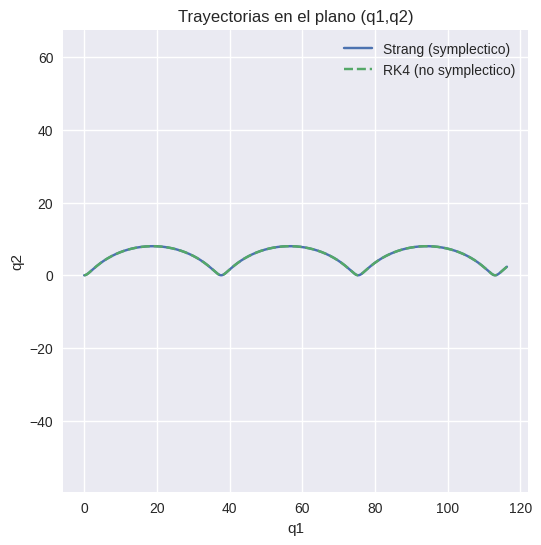

In [7]:
plt.figure(figsize=(6,6))
plt.plot(traj_s[:,0], traj_s[:,1], label="Strang (symplectico)")
plt.plot(traj_r[:,0], traj_r[:,1], '--', label="RK4 (no symplectico)")
plt.title("Trayectorias en el plano (q1,q2)")
plt.xlabel("q1"); plt.ylabel("q2")
plt.legend(); plt.grid(True); plt.axis("equal")
plt.show()



### 4.2 Evolución del momento (método de Strang)


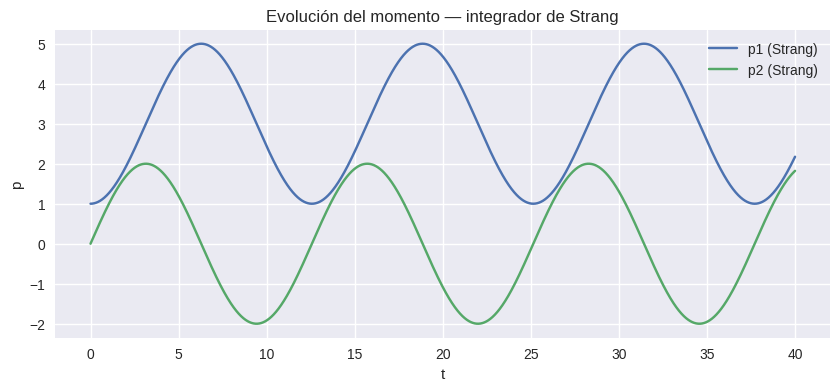

In [8]:
plt.figure(figsize=(10,4))
plt.plot(times_s, mom_s[:,0], label="p1 (Strang)")
plt.plot(times_s, mom_s[:,1], label="p2 (Strang)")
plt.title("Evolución del momento — integrador de Strang")
plt.xlabel("t"); plt.ylabel("p")
plt.legend(); plt.grid(True)
plt.show()



### 4.3 Energía física vs energía extendida vs RK4


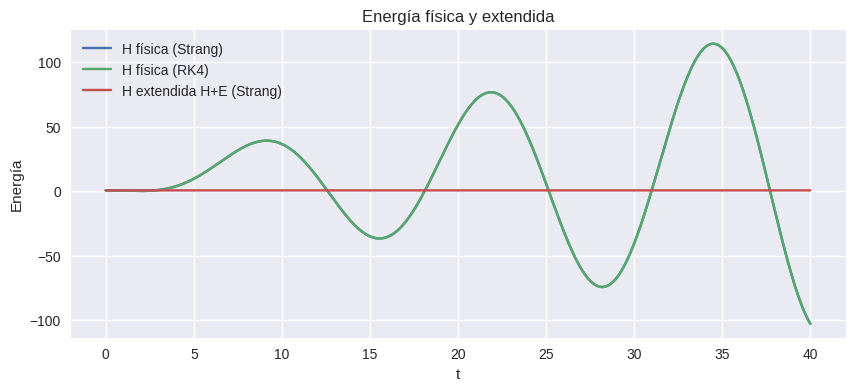

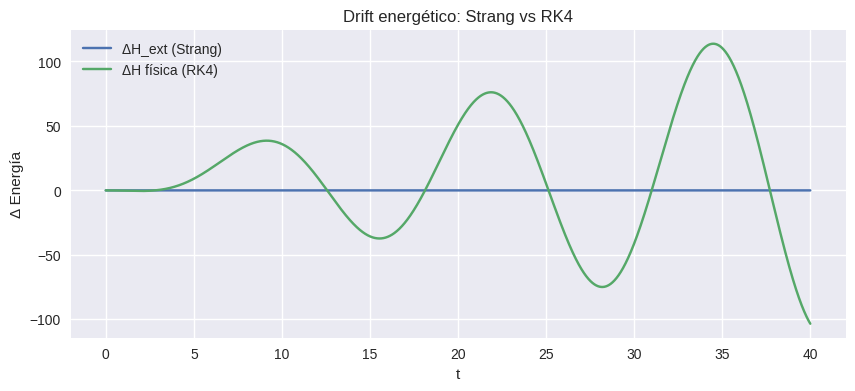

In [15]:
H_s = np.array(H_s)
H_r = np.array(H_r)
Hext_s = np.array(Hext_s)

plt.figure(figsize=(10,4))
plt.plot(times_s, H_s, label="H física (Strang)")
plt.plot(times_r, H_r, label="H física (RK4)")
plt.plot(times_s, Hext_s, label="H extendida H+E (Strang)")
plt.title("Energía física y extendida")
plt.xlabel("t"); plt.ylabel("Energía")
plt.legend(); plt.grid(True)
plt.show()

# Drift energético explícito
err_energy_strang = Hext_s - Hext_s[0]
err_energy_rk4 = H_r - H_r[0]

plt.figure(figsize=(10,4))
plt.plot(times_s, err_energy_strang, label="ΔH_ext (Strang)")
plt.plot(times_r, err_energy_rk4, label="ΔH física (RK4)")
plt.title("Drift energético: Strang vs RK4")
plt.xlabel("t"); plt.ylabel("Δ Energía")
plt.legend(); plt.grid(True)
plt.show()



## 5. Orden del método: error global vs $\Delta t$

Comprobamos numéricamente que el integrador de Strang es de **orden 2**,
midendo el error en la posición al tiempo final $T$ respecto a una solución
de referencia con paso muy fino.


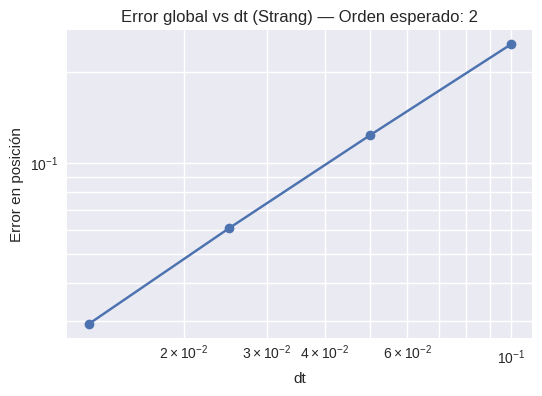

In [10]:
T = 2.0
dt_ref = 0.001
steps_ref = int(T/dt_ref)

traj_ref, _, _, _, _ = simulate_strang(q0, p0, t0, E0, dt_ref, steps_ref, E_func, E_dot_func)
q_ref = traj_ref[-1]

dts = [0.1, 0.05, 0.025, 0.0125]
errors = []

for dt_test in dts:
    steps_test = int(T/dt_test)
    traj_test, _, _, _, _ = simulate_strang(q0, p0, t0, E0, dt_test, steps_test, E_func, E_dot_func)
    q_test = traj_test[-1]
    errors.append(norm(q_test - q_ref))

plt.figure(figsize=(6,4))
plt.loglog(dts, errors, 'o-')
plt.title("Error global vs dt (Strang) — Orden esperado: 2")
plt.xlabel("dt"); plt.ylabel("Error en posición")
plt.grid(True, which="both")
plt.show()



## 6. Preservación de volumen: determinante del Jacobiano

Un mapa symplectico preserva el volumen de fase. A nivel numérico podemos aproximar
el Jacobiano del paso de Strang y estimar su determinante para comprobar que es
cercano a 1.


In [11]:
eps = 1e-6

def jacobian_step(q, p, t, Eext, dt, E_func, E_dot_func):
    x = np.hstack([q, p, [t, Eext]])  # dimensión 6 (2+2+1+1)
    n = len(x)
    J = np.zeros((n, n))
    f0_q, f0_p, f0_t, f0_E = strang_step(q, p, t, Eext, dt, E_func, E_dot_func)
    f0 = np.hstack([f0_q, f0_p, [f0_t, f0_E]])

    for i in range(n):
        dx = np.zeros_like(x)
        dx[i] = eps
        q1 = x[:2] + dx[:2]
        p1 = x[2:4] + dx[2:4]
        t1 = x[4] + dx[4]
        E1 = x[5] + dx[5]
        fq, fp, ft, fE = strang_step(q1, p1, t1, E1, dt, E_func, E_dot_func)
        f = np.hstack([fq, fp, [ft, fE]])
        J[:, i] = (f - f0) / eps

    return J

J = jacobian_step(q0, p0, t0, E0, dt, E_func, E_dot_func)
detJ = det(J)
print(f"det(J) ≈ {detJ:.6f}")
print(f"Error relativo |det(J)-1| ≈ {abs(detJ-1):.3e}")


det(J) ≈ 1.000000
Error relativo |det(J)-1| ≈ 8.274e-11



## 7. Resonancia paramétrica

Usamos ahora un campo eléctrico de la forma
$$
E(t) = (\sin(\omega t), 0),
$$
con una frecuencia elegida para inducir resonancia y observar cómo la partícula puede
ganar energía de forma coherente.


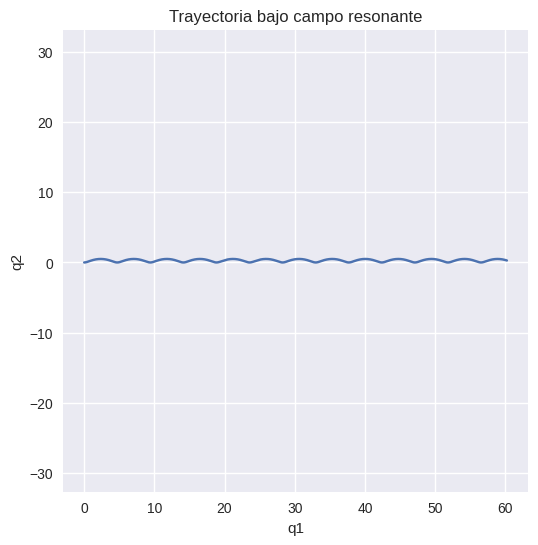

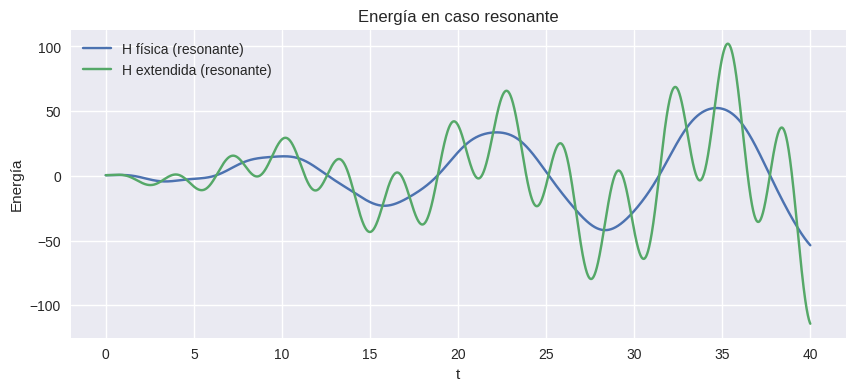

In [12]:
omega_res = 2.0
E_res, E_res_dot = make_field(omega_res)

traj_res, mom_res, times_res, H_res, Hext_res = simulate_strang(
    q0, p0, t0, E0, dt, steps, E_res, E_res_dot
)

plt.figure(figsize=(6,6))
plt.plot(traj_res[:,0], traj_res[:,1])
plt.title("Trayectoria bajo campo resonante")
plt.xlabel("q1"); plt.ylabel("q2")
plt.axis("equal"); plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(times_res, H_res, label="H física (resonante)")
plt.plot(times_res, Hext_res, label="H extendida (resonante)")
plt.title("Energía en caso resonante")
plt.xlabel("t"); plt.ylabel("Energía")
plt.legend(); plt.grid(True)
plt.show()



## 8. Animación de la trayectoria (Strang)

Animamos la trayectoria 2D obtenida con el integrador de Strang.


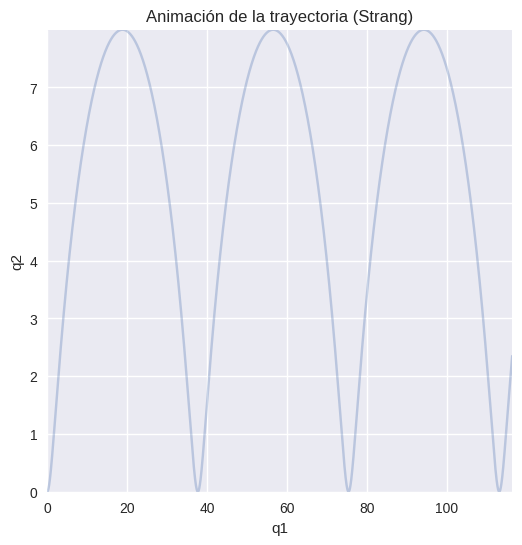

In [13]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(traj_s[:,0], traj_s[:,1], alpha=0.3)
ax.set_xlim(traj_s[:,0].min(), traj_s[:,0].max())
ax.set_ylim(traj_s[:,1].min(), traj_s[:,1].max())
ax.set_xlabel("q1"); ax.set_ylabel("q2")
ax.set_title("Animación de la trayectoria (Strang)")
ax.grid(True)

point, = ax.plot([], [], 'ro')

def update(i):
    point.set_data(traj_s[i,0], traj_s[i,1])
    return point,

ani = animation.FuncAnimation(fig, update, frames=len(traj_s), interval=10)
plt.show()



## 9. Conclusiones

1. El integrador symplectico por extensión Hamiltoniana y splitting de Strang
   muestra **excelente conservación de la energía extendida** y del volumen de fase.
2. El método de RK4, aunque de alto orden clásico, presenta **drift energético**
   apreciable a largo plazo, confirmando que no es adecuado para dinámica Hamiltoniana
   a tiempos largos.
3. El análisis de error global confirma empíricamente que el método de Strang es de
   **orden 2**.
4. El experimento de resonancia paramétrica ilustra cómo el método preserva fenómenos
   cualitativos relevantes, en línea con la predicción del backward error analysis.
